# Hierarchical Models

`caskade` is a very general simulator building framework, this includes hierarchical models. A hierarchical model is essentially a model within a model, and this can take several forms. Here we will demonstrate the basic patterns of hierarchical models that can be constructed in `caskade`, from which you should be able to build any simulator.

In [1]:
import caskade as ck
import torch
import matplotlib.pyplot as plt
import numpy as np


class Gaussian(ck.Module):
    def __init__(self, name, x0=None, q=None, phi=None, sigma=None, I0=None):
        super().__init__(name)
        self.x0 = ck.Param("x0", x0, shape=(2,))  # position
        self.q = ck.Param("q", q, shape=())  # axis ratio
        self.phi = ck.Param("phi", phi, shape=())  # orientation
        self.sigma = ck.Param("sigma", sigma, shape=())  # width
        self.I0 = ck.Param("I0", I0, shape=())  # intensity

    @ck.forward
    def _r(self, x, y, x0=None, q=None, phi=None):
        x, y = x - x0[..., 0], y - x0[..., 1]
        s, c = torch.sin(phi), torch.cos(phi)
        x, y = c * x - s * y, s * x + c * y
        return (x**2 + (y * q) ** 2).sqrt()

    @ck.forward
    def brightness(self, x, y, sigma=None, I0=None):
        return I0 * (-self._r(x, y) ** 2 / sigma**2).exp()


X, Y = torch.meshgrid(torch.linspace(-5, 5, 100), torch.linspace(-5, 5, 100), indexing="xy")

## Set param values during simulation (live params)

Sometimes you want your simulator to decide, within the simulation, what value a param should have. This is the simplest hierarchical model and can be created using a `static` param with a value of `None`, typically called a `Live param`. By being a `static` param, `caskade` will not expect the value as an input to the simulation, the `None` value tells `caskade` that it will be set during the simulation (anything else will mean `caskade` throws an error if you try to do this).

If this all sounds a lot like a `pointer` param, which `caskade` already has, you are right. Functionally, these two capabilities are nearly identical. As a rule of thumb, `pointer` params should be kept very light, either a direct pointer or a simple single (lambda) function to translate/combine a few params, while `live` params can do more heavy lifting as one can make use of the functions/utilities in the simulator quite easily (and more readably).

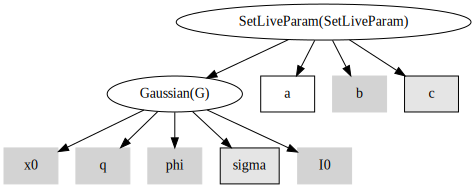

In [2]:
class SetLiveParam(ck.Module):
    def __init__(self, gaussian: Gaussian, a: float = 1.0, b: float = 2.0):
        super().__init__()
        self.gaussian = gaussian
        self.gaussian.sigma.to_static(None)  # Live param
        self.a = ck.Param("a", a, dynamic=True)
        self.b = ck.Param("b", b, dynamic=False)
        self.c = ck.Param("c", None, dynamic=False)  # Live param

    @ck.forward
    def determine_c(self, a, b):  # cannot request c here
        self.c = a + b

    @ck.forward
    def determine_sigma(self, a, b, c):
        self.gaussian.sigma = (a + b + c) / 2

    @ck.forward
    def main_sim(self, x, y, a, b):  # cannot request c here

        self.determine_c()

        self.determine_sigma()

        print("within sim c =", self.c.value.item())  # can manually get c after setting value

        return self.gaussian.brightness(x, y) * (a + b)


G = Gaussian("G", x0=[0, 0], q=1, phi=0, I0=1.0)
sim = SetLiveParam(G)
sim.graphviz()

Notice that the live params are greyed out like other `static` params, but also have a black border like `dynamic` params since they are somewhere in between the two.

within sim c = 3.0


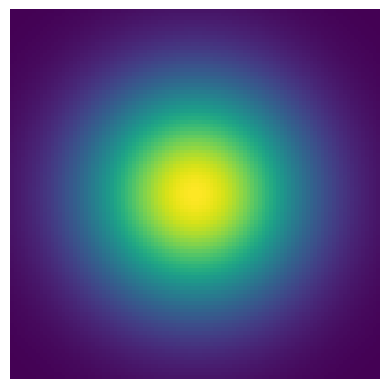

c is cleared after simulation (should be None): None
Gaussian sigma is cleared after simulation (should be None): None


In [3]:
plt.imshow(sim.main_sim(X, Y, sim.get_values()))
plt.axis("off")
plt.show()
print("c is cleared after simulation (should be None):", sim.c.value)
print("Gaussian sigma is cleared after simulation (should be None):", sim.gaussian.sigma.value)

## Batching a subgraph (hierarchical graphical models)

The goal of `caskade` is to support modular development of code. A quite common pattern is to develop a simulator to handle a single case, then use `vmap` to batch over many cases. This is great design and makes for very readable implementations that behave intuitively. All is well until you want that batched simulator to operate inside another simulator (see this real world example in `caustics`). Since `caksade` handles moving param values around for you, it is hard to call an internal function in a simulator with `vmap` as it expects all batched values to be passed at call time. This is where `caskade`'s hierarchical linking comes into play. 

In this example, lets use our gaussian blob. The code is designed to create a single gaussian blob, but with a batched simulator we can model multiple simultaneously. So now we will create an image with multiple blobs (similarly, one could model multiple images with a different blob in each).

x0 shape: (2,), x0 batched: True, x0 batch shape: (5,)


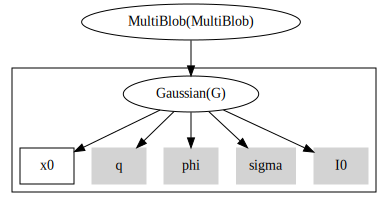

In [4]:
class MultiBlob(ck.Module):
    def __init__(self, gaussian):
        super().__init__()
        self.hierarchical_link(
            "gauss", gaussian
        )  # note, the name string is how we will reference the module

    @ck.forward
    def brightness(self, x, y, gauss_params, gauss_dims):
        batch_gauss = torch.vmap(self.gauss.brightness, in_dims=(None, None, gauss_dims))
        return batch_gauss(x, y, gauss_params).sum(dim=0)


G = Gaussian("G", q=1.0, phi=0.0, sigma=1.0, I0=1.0)
G.x0 = torch.tensor([[0, 0], [3, 1], [-2, 4], [-3, -3], [1, -4]])  # Batched param
print(f"x0 shape: {G.x0.shape}, x0 batched: {G.x0.batched}, x0 batch shape: {G.x0.batch_shape}")
Blobs = MultiBlob(G)
Blobs.graphviz()

Notice that there is a box around the part of the graph that is getting batched. This is a common notation for probabilistic graphical models to show that a subsection of the graph is repeated (batched) many times.

notice params is still a 1d tensor, so we can use it like normal:  torch.Size([10])


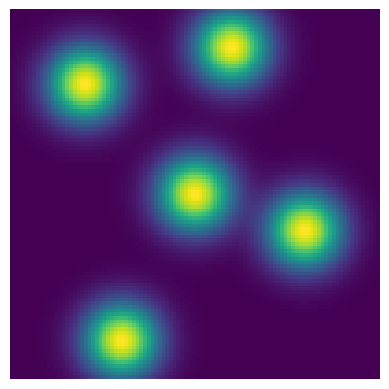

In [5]:
params = Blobs.get_values()
print("notice params is still a 1d tensor, so we can use it like normal: ", params.shape)
plt.imshow(Blobs.brightness(X, Y, Blobs.get_values()))
plt.axis("off")
plt.show()

Yay! Our single Gaussian module has now become a flexible batched Gaussian module. What's more, this is fully integrated into the `caskade` system. The model is a function of a 1d vector of values and so we could run MCMC/optimization/etc on it. This also means that we can take advantage of regular `caskade` batching on top of this. Prepare to have you brain bend a little bit.

Now the simulator is batched, the params are batched too:  torch.Size([6, 11])


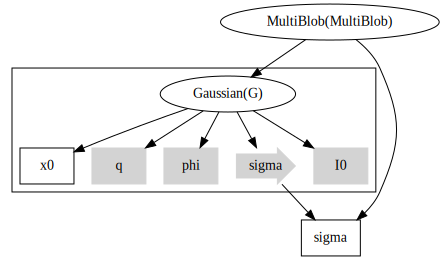

In [6]:
# Let's give blobs a sigma parameter to control the gaussian blob it owns
# We make the Blobs sigma a batched param, so now the simulator is batched
#                                                      v: batch size of 6
Blobs.sigma = ck.Param("sigma", torch.linspace(0.5, 2, 6), shape=(), dynamic=True)
G.sigma = Blobs.sigma  # Set the gaussian blob sigma to point to Blobs sigma
params = Blobs.get_values()
print("Now the simulator is batched, the params are batched too: ", params.shape)
Blobs.graphviz()

Notice how params (or modules) in the batched section of the graph can refer to params (or modules) outside the batched section. This is because of some clever aspects of how `caskade` works. Try not to think about it too much, everything should work intuitively.

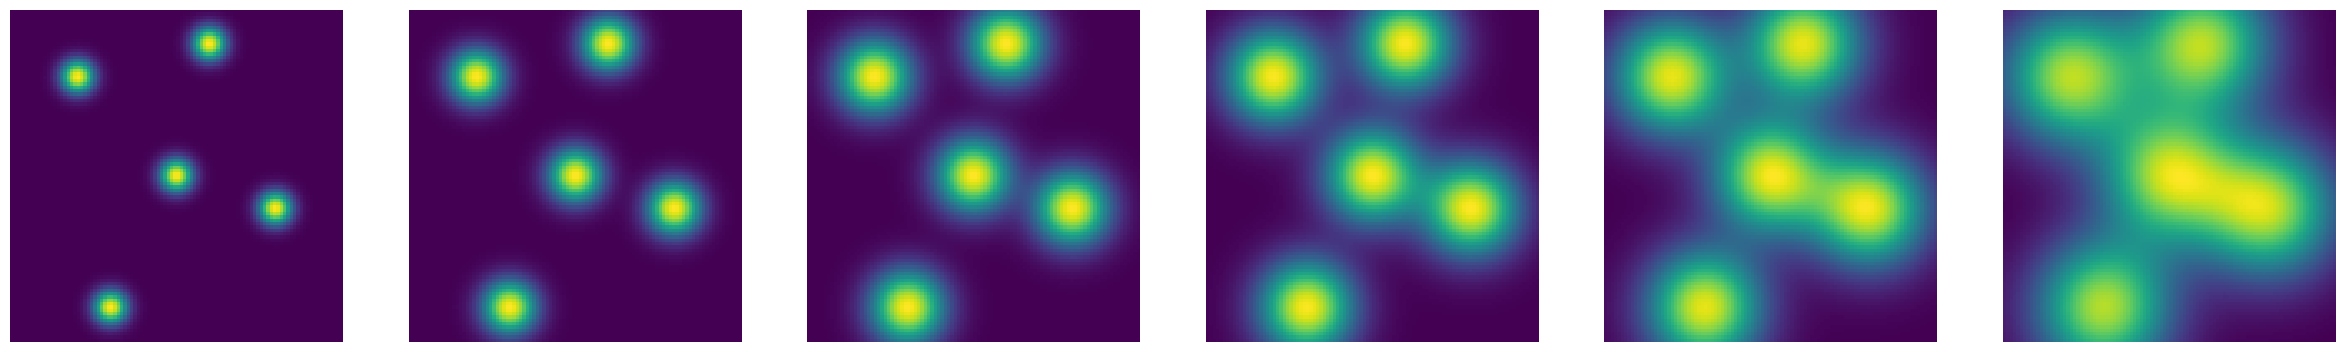

In [7]:
results = torch.vmap(Blobs.brightness, in_dims=(None, None, 0))(X, Y, params)
fig, axarr = plt.subplots(1, params.shape[0], figsize=(5 * params.shape[0], 6))
for ax, res in zip(axarr, results):
    ax.imshow(res)
    ax.axis("off")
plt.show()

This is very neat! But we cheated a bit by batching a param in the main graph. Can we batch the `x0` param that is part of the hierarchical graph? Yes, to keep it straight, just think "outside-in", the first batch dimension will be for the main simulator and the second batch dimension will be for the hierarchical simulator.

The Gaussian module on its own doesn't know what all the batch dims are for, only in the context of the full simulator do they get their meaning: (6, 5)
The Gaussian module mostly just knows that it should only ever actually see an x0 with this shape: (2,)
the 'params' has the same shape as before, just now instead of broadcasting the x0 shape it has a variety of values: torch.Size([6, 11])


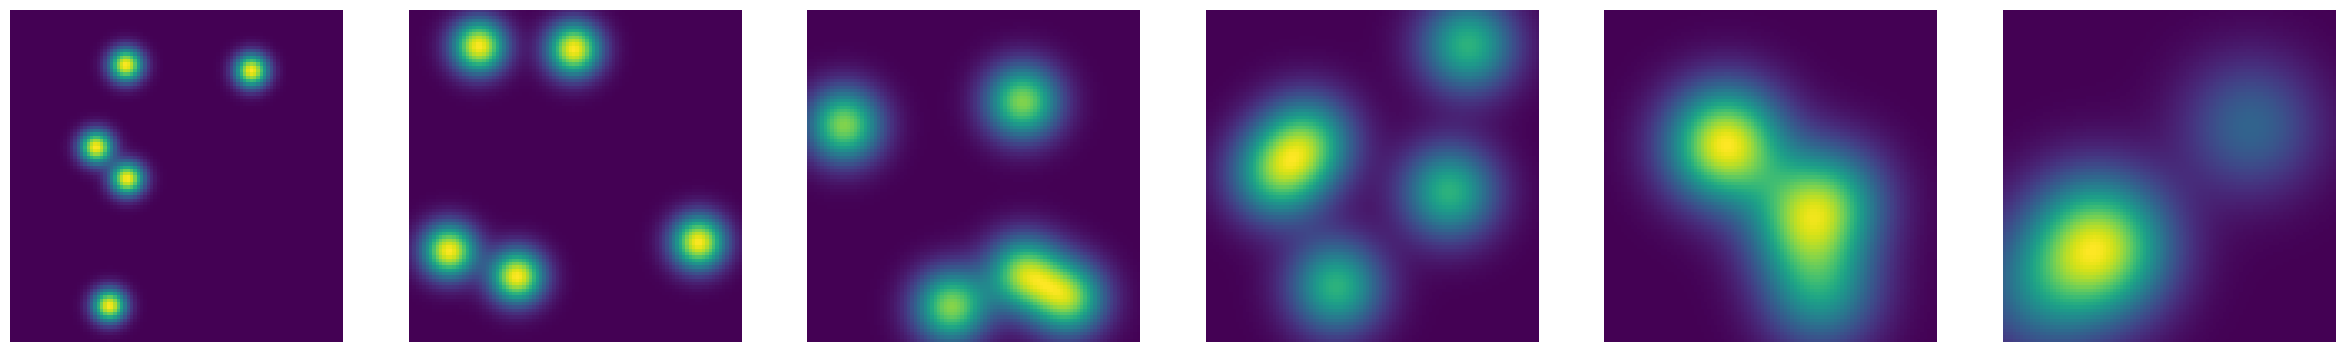

In [8]:
G.x0 = np.random.uniform(
    low=-4, high=4, size=(6, 5, 2)
)  # (main sim batch, hierarchical batch, x0 shape)
print(
    "The Gaussian module on its own doesn't know what all the batch dims are for, only in the context of the full simulator do they get their meaning:",
    G.x0.batch_shape,
)
print(
    "The Gaussian module mostly just knows that it should only ever actually see an x0 with this shape:",
    G.x0.shape,
)
params = Blobs.get_values()
print(
    "the 'params' has the same shape as before, just now instead of broadcasting the x0 shape it has a variety of values:",
    params.shape,
)
results = torch.vmap(Blobs.brightness, in_dims=(None, None, 0))(X, Y, params)
fig, axarr = plt.subplots(1, params.shape[0], figsize=(5 * params.shape[0], 6))
for ax, res in zip(axarr, results):
    ax.imshow(res)
    ax.axis("off")
plt.show()

## Going transdimensional, variable size batches inside the simulator

Sometimes when creating a forward model, we wish to specify population parameters and have the simulator create a sample from that population. It is possible to do this in `caskade`, though it does present some challenges given the typical workflow which involves specifying the shapes of all params in the simulation ahead of time. To make it work, we will have to construct the inputs to the batched simulator ourselves, inside the main simulator. The main tool that makes this feasible is the `dynamic_params` tuple, which gives us the order the params are expected in the simulator. Let's see how this works in a simple example that draws a population of gaussian blobs.

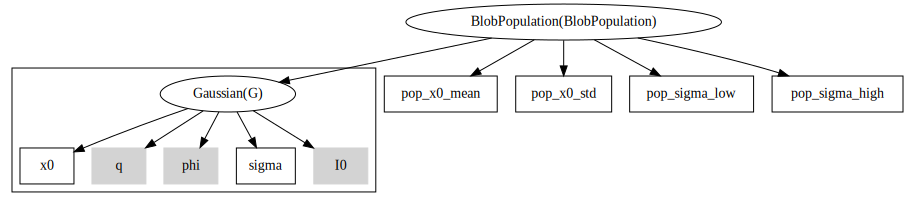

In [9]:
class BlobPopulation(ck.Module):
    def __init__(
        self, gaussian, pop_x0_mean=None, pop_x0_std=None, pop_sigma_low=None, pop_sigma_high=None
    ):
        super().__init__()
        self.hierarchical_link("gauss", gaussian)
        self.pop_x0_mean = ck.Param("pop_x0_mean", pop_x0_mean, shape=(2,))
        self.pop_x0_std = ck.Param("pop_x0_std", pop_x0_std, shape=(2,))
        self.pop_sigma_low = ck.Param("pop_sigma_low", pop_sigma_low, shape=())
        self.pop_sigma_high = ck.Param("pop_sigma_high", pop_sigma_high, shape=())

    @ck.forward
    def brightness(self, x, y, N, pop_x0_mean, pop_x0_std, pop_sigma_low, pop_sigma_high):
        # Randomly draw a number of members in the population
        n = np.random.poisson(N)

        # Sample values for the params
        params = {}
        expand = torch.ones(size=(n, 2))
        params["x0"] = torch.normal(
            mean=pop_x0_mean.unsqueeze(0) * expand, std=pop_x0_std.unsqueeze(0) * expand
        )
        params["sigma"] = torch.rand(n) * (pop_sigma_high - pop_sigma_low) + pop_sigma_low

        # Create params list
        params = list(params[p.name] for p in self.gauss.dynamic_params)
        dims = [0, 0]

        batch_gauss = torch.vmap(self.gauss.brightness, in_dims=(None, None, dims))
        return batch_gauss(x, y, params).sum(dim=0)


G = Gaussian("G", q=1.0, phi=0.0, I0=1.0)
G.x0.to_dynamic([0, 0])  # set dummy values for the params
G.sigma.to_dynamic(0)
G.x0.batch_shape = (1,)  # set filler batch shape
G.sigma.batch_shape = (1,)

BlobPop = BlobPopulation(G, [0, 0], [1, 4], 0.1, 1)
BlobPop.to_dynamic()
BlobPop.graphviz()

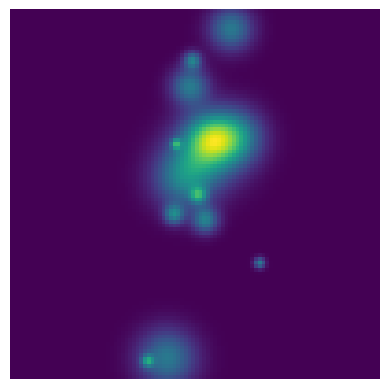

In [10]:
plt.imshow(BlobPop.brightness(X, Y, 20, BlobPop.get_values()))
plt.axis("off")
plt.show()

Now we can play around with the parameters and generate a new population!

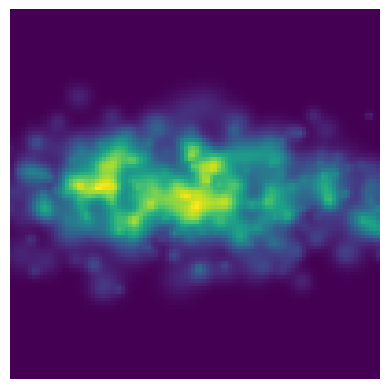

In [11]:
BlobPop.pop_x0_std = [3, 1]
BlobPop.pop_sigma_high = 0.5
plt.imshow(BlobPop.brightness(X, Y, 500, BlobPop.get_values()))
plt.axis("off")
plt.show()

And with that, you've simulated a population of gaussian blobs in an image. The `caskade` framework makes certain aspects of this kind of modelling very nice, mainly interacting with the population parameters in an intuitive/object-oriented way. Though there are some limitations. For example, such a simulator cannot be batched, since the variable size internal batch would conflict with any attempt to extend the tensors by adding an extra dimension. Further, the fact that you must construct the params yourself (inside the simulator) is somewhat fragile. Swapping out the Gaussian with a different type of blob model (say a Nuker profile) would require different inputs and so would crash the current setup; similarly changing which params of the Gaussian blob are dynamic would also crash the current version since it only generates a population with varying `x0` and `sigma`. Future updates may give a more robust framework for such a model, but for now we left the door open for users to have total flexibility in simulator construction.

As a tip for doing this kind of population modelling yourself, consider putting any metadata you need right alongside the params that need them. When you iterate over the `dynamic_params` tuple, it gives you access to the param objects and any meta data you wish to store, all in the correct order for passing to the hierarchical graph.

**This can also be achieved with live params**

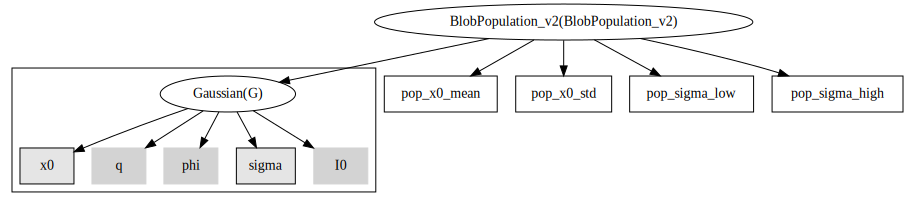

In [12]:
class BlobPopulation_v2(ck.Module):
    def __init__(
        self, gaussian, pop_x0_mean=None, pop_x0_std=None, pop_sigma_low=None, pop_sigma_high=None
    ):
        super().__init__()
        self.hierarchical_link("gauss", gaussian)
        self.pop_x0_mean = ck.Param("pop_x0_mean", pop_x0_mean, shape=(2,))
        self.pop_x0_std = ck.Param("pop_x0_std", pop_x0_std, shape=(2,))
        self.pop_sigma_low = ck.Param("pop_sigma_low", pop_sigma_low, shape=())
        self.pop_sigma_high = ck.Param("pop_sigma_high", pop_sigma_high, shape=())

    @ck.forward
    def sub_brightness(self, x, y, x0, sigma):
        self.gauss.x0 = x0
        self.gauss.sigma = sigma
        return self.gauss.brightness(x, y)

    @ck.forward
    def brightness(self, x, y, N, pop_x0_mean, pop_x0_std, pop_sigma_low, pop_sigma_high):
        # Randomly draw a number of members in the population
        n = np.random.poisson(N)

        # Sample values for the params
        expand = torch.ones(size=(n, 2))
        x0 = torch.normal(
            mean=pop_x0_mean.unsqueeze(0) * expand, std=pop_x0_std.unsqueeze(0) * expand
        )
        sigma = torch.rand(n) * (pop_sigma_high - pop_sigma_low) + pop_sigma_low

        batch_gauss = torch.vmap(self.sub_brightness, in_dims=(None, None, 0, 0))
        return batch_gauss(x, y, x0, sigma).sum(dim=0)


G = Gaussian("G", q=1.0, phi=0.0, I0=1.0)
G.x0.to_static()
G.sigma.to_static()

BlobPop = BlobPopulation_v2(G, [0, 0], [1, 4], 0.1, 1)
BlobPop.to_dynamic()
BlobPop.graphviz()

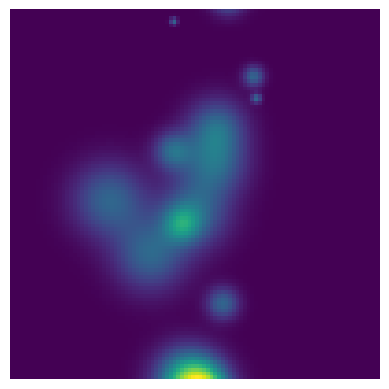

In [13]:
plt.imshow(BlobPop.brightness(X, Y, 20, BlobPop.get_values()))
plt.axis("off")
plt.show()

Whichever form is most intuitive to you should work fine. 

Note as well that we didn't really need to make the `Gaussian` a hierarchical graph in this case. The live params are where the batching happens and we did that ourselves. It may still be useful to make a hierarchical link for mentally keeping track of the batching, but this is up to you.